# 02A: Custom Circuit Generation

Construct a memory experiment circuit using the `custom` strategy with a BB code.

- **Strategy used in this notebook:** `custom`
- **Codes that support `custom`:** `BbCode`
- `custom` is BB-specific and uses a hand-designed measurement schedule.

In [1]:
from quits.circuit import check_overlapping_CX
from quits import ErrorModel, CircuitBuildOptions
from quits.layout import ToricLayout, TransversalLayout
from quits.qldpc_code import BbCode

In [2]:
# Common parameters
p = 1e-3
num_rounds = 15

error_model = ErrorModel(
    idle_error=p,
    sqgate_error=p,
    tqgate_error=p,
    spam_error=p,
)

circuit_build_options = CircuitBuildOptions(
    get_all_detectors=False,
    noisy_zeroth_round=True,
    noisy_final_meas=False,
)

In [3]:
# BB code example
code = BbCode(
    l=6,
    m=6,
    A_x_pows=[3],
    A_y_pows=[1, 2],
    B_x_pows=[1, 2],
    B_y_pows=[3],
)

In [4]:
# Build memory circuit with custom strategy
circuit = code.build_circuit(
    strategy="custom",
    error_model=error_model,
    num_rounds=num_rounds,
    basis="Z",
    circuit_build_options=circuit_build_options,
)

check_overlapping_CX(circuit)
print("Entangling depth:", code.depth)
print(circuit)

No overlapping CX gates found.
Entangling depth: 7
R 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107
X_ERROR(0.001) 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107
R 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
X_ERROR(0.001) 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 3

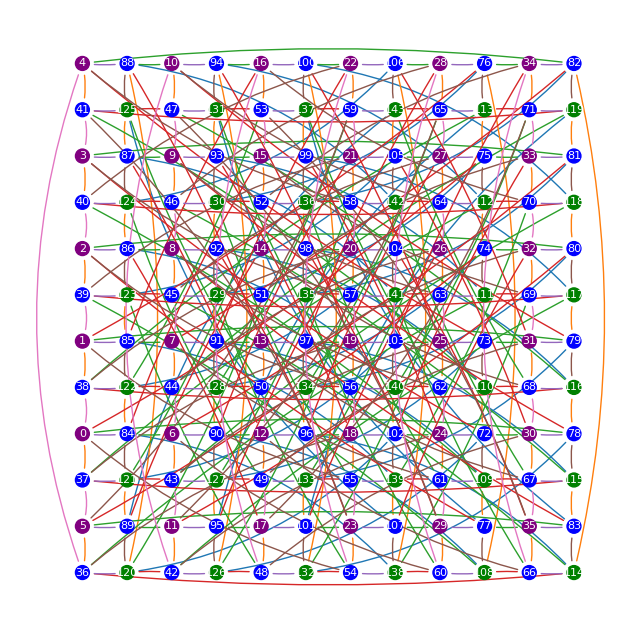

In [ ]:
toric_layout = ToricLayout(code)
code.draw_graph(toric_layout, part='all', curved_edges=True, figsize=(8,8))


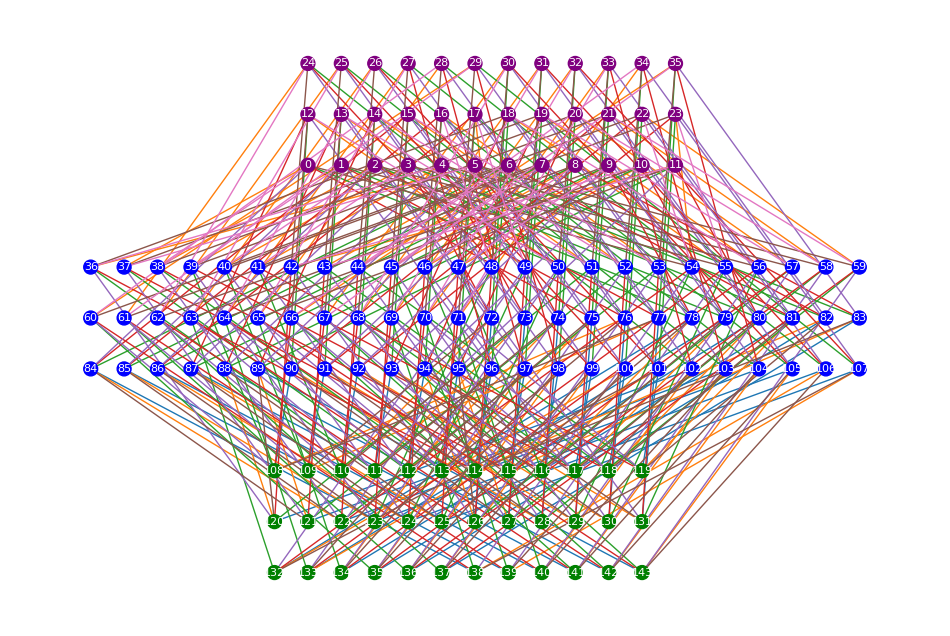

In [ ]:
transversal_layout = TransversalLayout(code, data_rows=3, zcheck_rows=3, xcheck_rows=3)
code.draw_graph(transversal_layout, part='all', figsize=(12,8))
